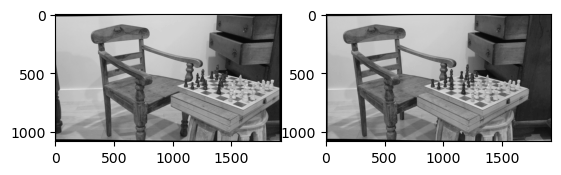

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

focal_length = 1758.23      # in pixels
baseline =0.12486        # in meters

img_left = cv2.imread('im0.png')
img_right = cv2.imread('im1.png')

img_left_rgb = cv2.cvtColor(img_left, cv2.COLOR_BGR2RGB)
img_right_rgb = cv2.cvtColor(img_right, cv2.COLOR_BGR2RGB)

gray_left = cv2.cvtColor(img_left_rgb, cv2.COLOR_BGR2GRAY)
gray_right = cv2.cvtColor(img_right_rgb, cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(gray_left,cmap='gray')
plt.subplot(1,2,2)
plt.imshow(gray_right,cmap='gray')

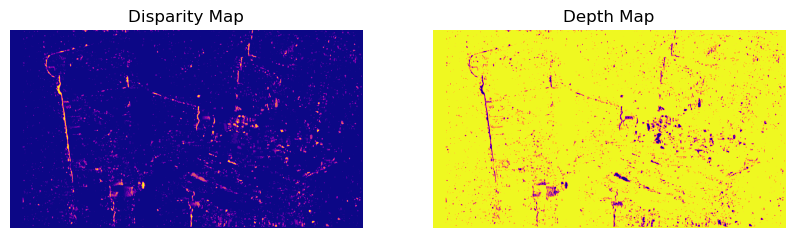

In [2]:
num_disparities = 64
block_size = 15

stereo = cv2.StereoBM_create(numDisparities=num_disparities, blockSize=block_size)
disparity = stereo.compute(gray_left, gray_right).astype(np.float32)

disparity[disparity <= 0] = 1.0

depth_map = (focal_length * baseline) / disparity

depth_normalized = cv2.normalize(depth_map, None, 0, 255, cv2.NORM_MINMAX)
depth_normalized = np.uint8(depth_normalized)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(disparity, cmap='plasma')
plt.title("Disparity Map")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(depth_normalized, cmap='plasma')
plt.title("Depth Map")
plt.axis('off')

plt.show()